# Song Emotion Modelling

**Dataset:** Spotify audio features (1,202 unique tracks after deduplication) merged with MuSe/Last.fm emotion tags.

**Targets:**
- *Regression:* `valence_tags`, `arousal_tags`, `dominance_tags` (continuous, scale ~1–9)
- *Classification:* `arousal_level` (3 classes: low / mid / high, derived via equal-frequency binning of `arousal_tags`)

**Model philosophy:** Start simple → build up. Emphasise explainability throughout. Use **5-fold cross-validation** as the primary evaluation method for all models.

**Sections:**
1. Data Preparation
2. Regression Modelling (Linear Regression, Ridge, Shallow MLP)
3. Classification Modelling (Logistic Regression, Decision Tree, Random Forest, Shallow MLP)

In [2]:
pip install scikit-learn pandas matplotlib seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 49.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 57.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 71.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 62.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 65.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 52.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 69.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]2/14 [matplotlib]n]
Note: you may need to restart the kernel to use updated packages.


## 1. Data Preparation

Load the raw CSV, deduplicate on `spotify_id`, define features and targets, apply log₁ₚ transforms to four right-skewed features (`speechiness`, `instrumentalness`, `liveness`, `duration_ms`), and standardise.

In [3]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

print("All imports loaded successfully.")


# =============================================================================
# SECTION 2: DATA LOADING AND CLEANING
# =============================================================================

# --- Load data (try relative path, fall back to current directory) ---
try:
    df_raw = pd.read_csv('../data.csv', index_col=0)
    print("Loaded data from '../data.csv'")
except FileNotFoundError:
    df_raw = pd.read_csv('data.csv', index_col=0)
    print("Loaded data from 'data.csv'")

print(f"Raw shape: {df_raw.shape}")

# --- Deduplicate on spotify_id ---
# Each unique Spotify track should appear only once; keep the first occurrence
df = df_raw.drop_duplicates(subset='spotify_id', keep='first').copy()
print(f"Shape after deduplication on spotify_id: {df.shape}  "
      f"(removed {df_raw.shape[0] - df.shape[0]} duplicate rows)")

# --- Drop rows where any regression target is null ---
# valence_tags, arousal_tags, dominance_tags are required for all modelling tasks
targets = ['valence_tags', 'arousal_tags', 'dominance_tags']
before = df.shape[0]
df = df.dropna(subset=targets).copy()
print(f"Shape after dropping null targets: {df.shape}  "
      f"(removed {before - df.shape[0]} rows with missing target values)")

# --- Reset index for clean integer indexing ---
df = df.reset_index(drop=True)

# --- Quick missing-value audit on remaining data ---
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nRemaining columns with missing values:")
print(missing if not missing.empty else "  None")


# =============================================================================
# SECTION 3: FEATURE DEFINITION
# =============================================================================

# --- Regression targets ---
y_reg = df[['valence_tags', 'arousal_tags', 'dominance_tags']].copy()

# --- Classification target: bin arousal_tags into 3 equal-frequency classes ---
# pd.qcut ensures each bin contains roughly the same number of observations
df['arousal_level'] = pd.qcut(
    df['arousal_tags'],
    q=3,
    labels=['low', 'mid', 'high']
)
y_clf = df[['arousal_level']].copy()

# --- Base feature set (14 audio + metadata features) ---
# Selected based on EDA relevance and domain knowledge
FEATURE_COLS = [
    'popularity',             # Spotify popularity score
    'duration_ms',            # Track length (milliseconds)
    'danceability',           # Rhythmic suitability for dancing
    'energy',                 # Perceptual intensity and activity
    'key',                    # Pitch class (0-11, treated as ordinal)
    'loudness',               # Overall loudness in dB
    'mode',                   # Major (1) or minor (0)
    'speechiness',            # Presence of spoken words
    'acousticness',           # Acoustic confidence measure
    'instrumentalness',       # Likelihood of no vocals
    'liveness',               # Presence of live audience
    'valence',                # Musical positiveness
    'tempo',                  # Beats per minute
    'number_of_emotion_tags'  # Count of user-assigned emotion tags
]

X = df[FEATURE_COLS].copy()

print(f"\nBase feature matrix X: {X.shape}  ({len(FEATURE_COLS)} features, {X.shape[0]} samples)")
print(f"Regression targets y_reg: {y_reg.shape}")
print(f"Classification target y_clf: {y_clf.shape}")


# =============================================================================
# SECTION 4: FEATURE TRANSFORMATIONS
# =============================================================================

# --- Log1p transforms for right-skewed features ---
# EDA skewness: speechiness=3.71, duration_ms=3.20, liveness=2.34, instrumentalness=1.57
# log1p is used (instead of log) to safely handle zero values
LOG_TRANSFORM_COLS = ['speechiness', 'instrumentalness', 'liveness', 'duration_ms']

X_transformed = X.copy()
for col in LOG_TRANSFORM_COLS:
    X_transformed[col] = np.log1p(X_transformed[col])

print("Log1p transforms applied to:", LOG_TRANSFORM_COLS)

# --- Correlation comparison: raw vs. transformed features vs. arousal_tags ---
arousal = df['arousal_tags']

print("\nCorrelation with arousal_tags — raw vs. log1p-transformed:")
print(f"{'Feature':<25} {'Raw':>10} {'Transformed':>14}")
print("-" * 52)
for col in FEATURE_COLS:
    raw_corr  = X[col].corr(arousal)
    trans_corr = X_transformed[col].corr(arousal)
    marker = "  <-- improved" if abs(trans_corr) > abs(raw_corr) and col in LOG_TRANSFORM_COLS else ""
    print(f"{col:<25} {raw_corr:>10.4f} {trans_corr:>14.4f}{marker}")

print("\nNote: log1p reduces right skew, which can improve linear model assumptions "
      "and correlation linearity.")


# =============================================================================
# SECTION 5: STANDARD SCALING
# =============================================================================

# --- Scaler for base features ---
scaler_base = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_base.fit_transform(X),
    columns=FEATURE_COLS,
    index=X.index
)

# --- Scaler for log-transformed features ---
scaler_trans = StandardScaler()
X_transformed_scaled = pd.DataFrame(
    scaler_trans.fit_transform(X_transformed),
    columns=FEATURE_COLS,
    index=X_transformed.index
)

# IMPORTANT: Both scalers are fit on the full dataset — appropriate for exploratory
# analysis and visualisation. In cross-validation loops, scalers MUST be fit only on
# the training fold and applied (transform-only) to the validation fold to prevent
# data leakage. sklearn's cross_val_score handles this when used with a Pipeline.

print("StandardScaler applied to both feature sets (fit on full data — for exploration only).")
print(f"  X_scaled shape:             {X_scaled.shape}")
print(f"  X_transformed_scaled shape: {X_transformed_scaled.shape}")


# =============================================================================
# SECTION 6: DATASET SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("DATASET PREPARATION SUMMARY")
print("=" * 60)

print(f"\nFinal cleaned dataset shape:      {df.shape}")
print(f"Base feature matrix (X):          {X.shape}")
print(f"Transformed feature matrix:       {X_transformed.shape}")
print(f"Scaled base features:             {X_scaled.shape}")
print(f"Scaled transformed features:      {X_transformed_scaled.shape}")

print(f"\nRegression targets (y_reg):       {y_reg.shape}")
print(y_reg.describe().round(4).to_string())

print(f"\nClassification target (y_clf) — arousal_level class distribution:")
counts = y_clf['arousal_level'].value_counts().sort_index()
pcts   = (counts / counts.sum() * 100).round(1)
for label in ['low', 'mid', 'high']:
    print(f"  {label:>4}:  {counts[label]:>4} samples  ({pcts[label]}%)")

print(f"\nFeatures ({len(FEATURE_COLS)}):", FEATURE_COLS)
print(f"\nLog1p-transformed features: {LOG_TRANSFORM_COLS}")

print("\n" + "=" * 60)
print("Data preparation complete. Ready for modelling.")
print("=" * 60)

All imports loaded successfully.
Loaded data from 'data.csv'
Raw shape: (1697, 31)
Shape after deduplication on spotify_id: (1202, 31)  (removed 495 duplicate rows)
Shape after dropping null targets: (1202, 31)  (removed 0 rows with missing target values)

Remaining columns with missing values:
mbid    224
dtype: int64

Base feature matrix X: (1202, 14)  (14 features, 1202 samples)
Regression targets y_reg: (1202, 3)
Classification target y_clf: (1202, 1)
Log1p transforms applied to: ['speechiness', 'instrumentalness', 'liveness', 'duration_ms']

Correlation with arousal_tags — raw vs. log1p-transformed:
Feature                          Raw    Transformed
----------------------------------------------------
popularity                    0.0903         0.0903
duration_ms                  -0.1282        -0.1403  <-- improved
danceability                  0.1694         0.1694
energy                        0.3294         0.3294
key                          -0.0130        -0.0130
loudness 

## 2. Regression Modelling

Predict the three continuous emotion dimensions (`valence_tags`, `arousal_tags`, `dominance_tags`) from Spotify audio features. All models are evaluated with **5-fold cross-validation** — every reported MSE and R² is averaged over held-out folds.

Models covered:
- **R2** Linear Regression (raw features) — interpretability baseline
- **R3** Linear Regression (log-transformed features) — checks skew reduction
- **R4** Ridge Regression — handles correlated features
- **R5** Shallow MLP — non-linear exploration
- **R6** Comparison table

### R1: Setup and Helper Function

Define the shared 5-fold `KFold` splitter and the `cv_regression_report` helper that runs cross-validation per target and accumulates results.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_val_score

# Shared 5-fold CV splitter used in every regression subsection
CV = KFold(n_splits=5, shuffle=True, random_state=42)

# Target column names (must match y_reg columns)
TARGETS = ["valence_tags", "arousal_tags", "dominance_tags"]

# Accumulates per-model results for the final comparison table (R6)
results_store = {}

In [14]:
# =============================================================================
# R1 — HELPER FUNCTION
# =============================================================================

def cv_regression_report(model, X, y_reg, cv, label):
    '''
    Run 5-fold CV for each regression target and report per-target and
    overall-average MSE and R2.

    Parameters
    ----------
    model   : sklearn estimator (single-output; called once per target)
    X       : feature matrix (numpy array or DataFrame)
    y_reg   : DataFrame with columns valence_tags, arousal_tags, dominance_tags
    cv      : cross-validation splitter (e.g. the shared KFold instance)
    label   : string identifier used in result storage and printing

    Returns
    -------
    record  : dict with "label", per-target MSE/R2, and "avg_mse"/"avg_r2"
    '''
    per_target_mse = {}
    per_target_r2  = {}

    print(f"\n{'='*60}")
    print(f"  Cross-Validation Report — {label}")
    print(f"{'='*60}")

    for target in TARGETS:
        y_col = y_reg[target].values  # 1-D array for this target

        neg_mse_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
        r2_scores = cross_val_score(
            model, X, y_col,
            cv=cv,
            scoring="r2"
        )

        mean_mse = -neg_mse_scores.mean()
        mean_r2  =  r2_scores.mean()

        per_target_mse[target] = mean_mse
        per_target_r2[target]  = mean_r2

        print(f"  {target:<22}  CV MSE = {mean_mse:.4f}   CV R2 = {mean_r2:.4f}")

    avg_mse = np.mean(list(per_target_mse.values()))
    avg_r2  = np.mean(list(per_target_r2.values()))
    print(f"  {'[AVERAGE]':<22}  CV MSE = {avg_mse:.4f}   CV R2 = {avg_r2:.4f}")
    print(f"{'='*60}")

    record = {"label": label, "avg_mse": avg_mse, "avg_r2": avg_r2}
    for t in TARGETS:
        record[f"mse_{t}"] = per_target_mse[t]
        record[f"r2_{t}"]  = per_target_r2[t]

    results_store[label] = record
    return record

### R2: Linear Regression — Baseline (Raw Features)

Ordinary least squares on 14 standardised audio features. Coefficients show the direct, linear relationship between each feature and the emotion score, sorted by absolute magnitude for easy reading.


  Cross-Validation Report — LR — Raw Features
  valence_tags            CV MSE = 2.1793   CV R2 = 0.0896
  arousal_tags            CV MSE = 1.0140   CV R2 = 0.1397
  dominance_tags          CV MSE = 1.1559   CV R2 = 0.0698
  [AVERAGE]               CV MSE = 1.4498   CV R2 = 0.0997


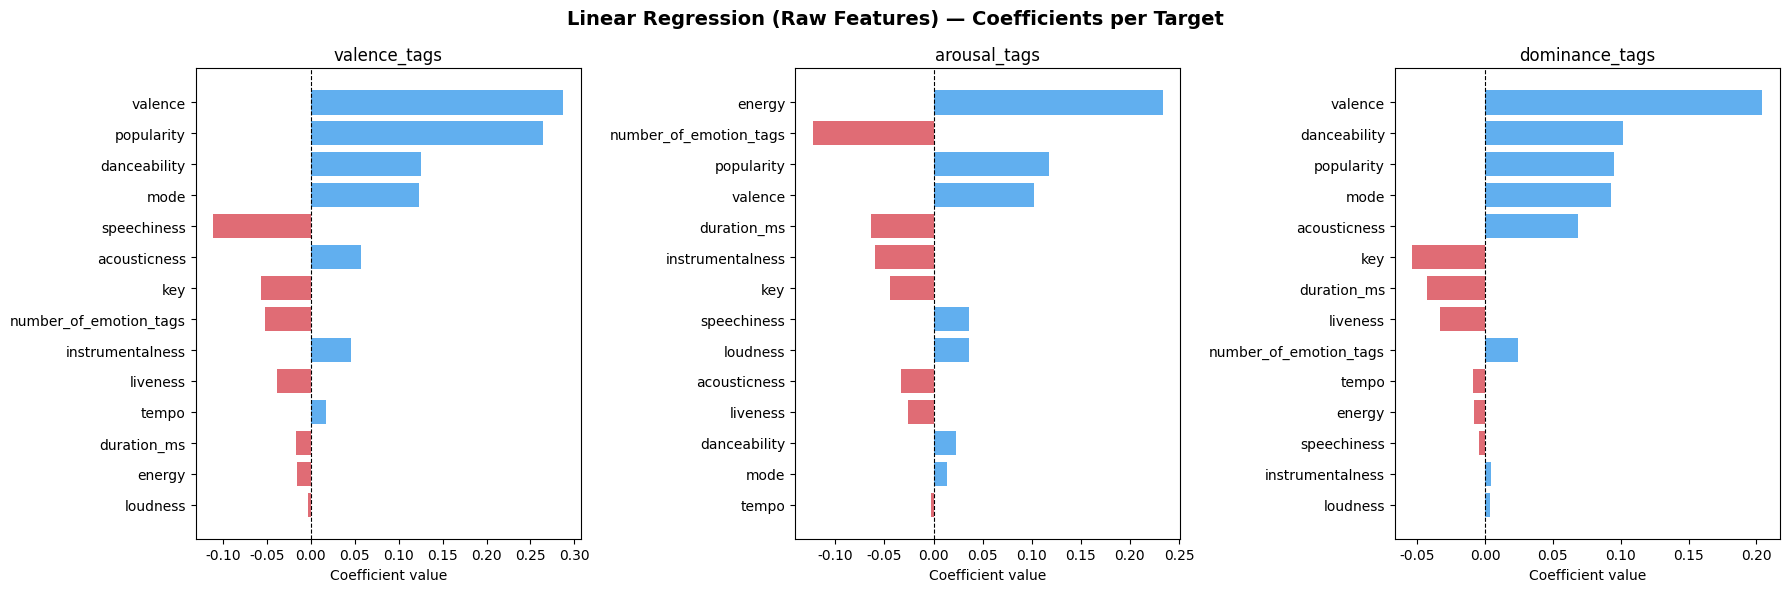


Top-3 most important features by |coefficient| — Raw Linear Regression
------------------------------------------------------------

  valence_tags:
    1. valence                      coef = +0.2874  (positive)
    2. popularity                   coef = +0.2643  (positive)
    3. danceability                 coef = +0.1256  (positive)

  arousal_tags:
    1. energy                       coef = +0.2337  (positive)
    2. number_of_emotion_tags       coef = -0.1231  (negative)
    3. popularity                   coef = +0.1171  (positive)

  dominance_tags:
    1. valence                      coef = +0.2044  (positive)
    2. danceability                 coef = +0.1016  (positive)
    3. popularity                   coef = +0.0947  (positive)

Coefficient interpretation:
  Because all features are standardised (mean=0, std=1), coefficient
  magnitudes are directly comparable within the same target.  A positive
  coefficient means that a one-standard-deviation increase in the feature
  

In [15]:
# =============================================================================
# R2 — LINEAR REGRESSION (RAW FEATURES)
# =============================================================================

lr_base = LinearRegression()

# 5-fold CV evaluation
lr_base_record = cv_regression_report(
    lr_base, X_scaled, y_reg, CV,
    label="LR — Raw Features"
)

# ---- Fit on full data to extract coefficients for interpretability ----------
lr_base_fitted_coefs = {}
for target in TARGETS:
    lr_base.fit(X_scaled, y_reg[target].values)
    lr_base_fitted_coefs[target] = lr_base.coef_.copy()

# ---- Plot: horizontal bar charts, one subplot per target -------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Linear Regression (Raw Features) — Coefficients per Target",
    fontsize=14, fontweight="bold"
)

for ax, target in zip(axes, TARGETS):
    coefs  = lr_base_fitted_coefs[target]
    order           = np.argsort(np.abs(coefs))
    sorted_features = np.array(FEATURE_COLS)[order]
    sorted_coefs    = coefs[order]
    colors = ["#e06c75" if c < 0 else "#61afef" for c in sorted_coefs]
    ax.barh(sorted_features, sorted_coefs, color=colors)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(target, fontsize=12)
    ax.set_xlabel("Coefficient value")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.savefig("r2_lr_base_coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

# ---- Top-3 most important features per target ------------------------------
print("\nTop-3 most important features by |coefficient| — Raw Linear Regression")
print("-" * 60)
for target in TARGETS:
    coefs   = lr_base_fitted_coefs[target]
    top_idx = np.argsort(np.abs(coefs))[::-1][:3]
    print(f"\n  {target}:")
    for rank, idx in enumerate(top_idx, 1):
        direction = "positive" if coefs[idx] > 0 else "negative"
        print(
            f"    {rank}. {FEATURE_COLS[idx]:<28} "
            f"coef = {coefs[idx]:+.4f}  ({direction})"
        )

print('''
Coefficient interpretation:
  Because all features are standardised (mean=0, std=1), coefficient
  magnitudes are directly comparable within the same target.  A positive
  coefficient means that a one-standard-deviation increase in the feature
  raises the predicted emotion score; a negative coefficient lowers it.
''')

### R3: Linear Regression — Log Transforms

Four right-skewed features are log₁ₚ-transformed before fitting. We compare CV MSE to the baseline and visualise how the transforms shift the learned coefficients.


  Cross-Validation Report — LR — Log-Transformed Features
  valence_tags            CV MSE = 2.1766   CV R2 = 0.0909
  arousal_tags            CV MSE = 1.0080   CV R2 = 0.1448
  dominance_tags          CV MSE = 1.1546   CV R2 = 0.0709
  [AVERAGE]               CV MSE = 1.4464   CV R2 = 0.1022

CV MSE Comparison — Raw vs. Log-Transformed Features
Target                      Raw MSE    Transformed MSE    Delta MSE            
---------------------------------------------------------------------------
  valence_tags               2.1793             2.1766      -0.0028  better
  arousal_tags               1.0140             1.0080      -0.0060  better
  dominance_tags             1.1559             1.1546      -0.0013  better
  [AVERAGE]                  1.4498             1.4464      -0.0034


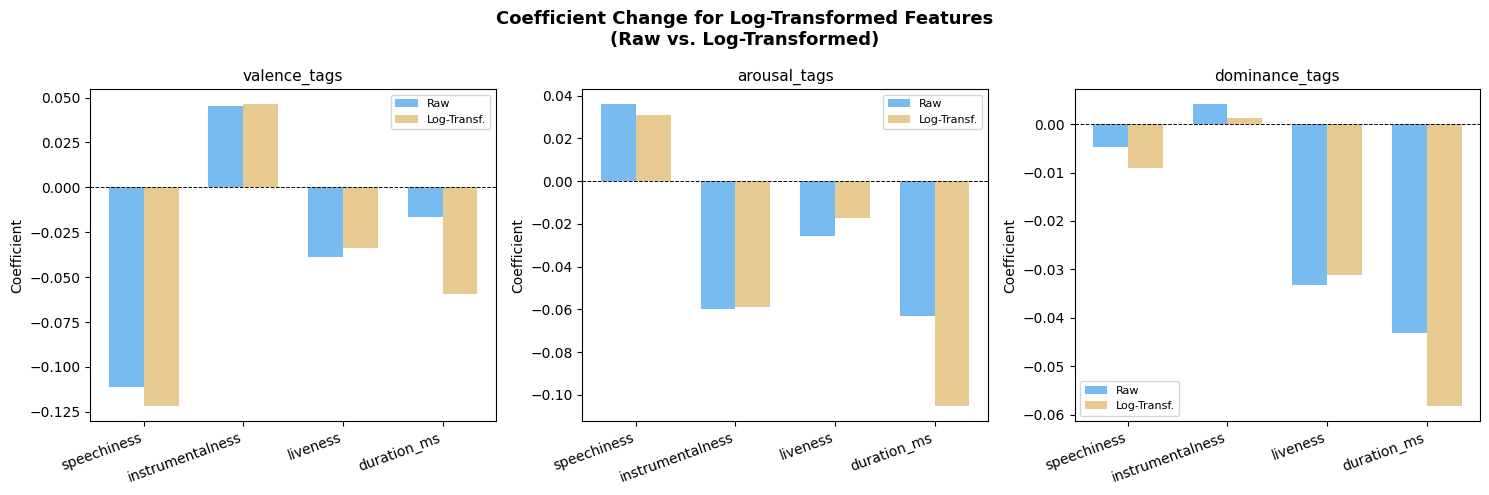


Interpretation:
  Log1p-transforming right-skewed features compresses large outliers and can
  linearise a feature's relationship with the target.  Where a transformed
  coefficient differs substantially from its raw counterpart, the log scale
  provides a better-fitting monotone link between that feature and the emotion
  dimension.  Stable coefficient directions (sign unchanged) confirm the
  transform has not distorted the qualitative interpretation.



In [16]:
# =============================================================================
# R3 — LINEAR REGRESSION (LOG-TRANSFORMED FEATURES)
# =============================================================================

lr_transformed = LinearRegression()

# 5-fold CV on the transformed & scaled features
lr_transformed_record = cv_regression_report(
    lr_transformed, X_transformed_scaled, y_reg, CV,
    label="LR — Log-Transformed Features"
)

# ---- Improvement table: CV MSE raw vs. transformed -------------------------
print("\nCV MSE Comparison — Raw vs. Log-Transformed Features")
print(f"{'Target':<24} {'Raw MSE':>10} {'Transformed MSE':>18} {'Delta MSE':>12}  {'':>10}")
print("-" * 75)
for target in TARGETS:
    raw_mse = lr_base_record[f"mse_{target}"]
    trf_mse = lr_transformed_record[f"mse_{target}"]
    delta   = trf_mse - raw_mse
    note    = "better" if delta < 0 else "worse "
    print(
        f"  {target:<22} {raw_mse:>10.4f} {trf_mse:>18.4f} "
        f"{delta:>+12.4f}  {note}"
    )
avg_raw = lr_base_record["avg_mse"]
avg_trf = lr_transformed_record["avg_mse"]
print(
    f"  {'[AVERAGE]':<22} {avg_raw:>10.4f} {avg_trf:>18.4f} "
    f"{avg_trf - avg_raw:>+12.4f}"
)

# ---- Fit transformed model on full data to extract coefficients ------------
lr_transformed_fitted_coefs = {}
for target in TARGETS:
    lr_transformed.fit(X_transformed_scaled, y_reg[target].values)
    lr_transformed_fitted_coefs[target] = lr_transformed.coef_.copy()

# ---- Coefficient comparison plot: raw vs. transformed (4 log features) ----
LOG_FEATURES = ["speechiness", "instrumentalness", "liveness", "duration_ms"]
log_indices  = [FEATURE_COLS.index(f) for f in LOG_FEATURES]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Coefficient Change for Log-Transformed Features\n(Raw vs. Log-Transformed)",
    fontsize=13, fontweight="bold"
)

x     = np.arange(len(LOG_FEATURES))
width = 0.35

for ax, target in zip(axes, TARGETS):
    raw_coefs = lr_base_fitted_coefs[target][log_indices]
    trf_coefs = lr_transformed_fitted_coefs[target][log_indices]
    ax.bar(x - width/2, raw_coefs, width, label="Raw",         color="#61afef", alpha=0.85)
    ax.bar(x + width/2, trf_coefs, width, label="Log-Transf.", color="#e5c07b", alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(target, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(LOG_FEATURES, rotation=20, ha="right")
    ax.set_ylabel("Coefficient")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("r3_lr_coef_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print('''
Interpretation:
  Log1p-transforming right-skewed features compresses large outliers and can
  linearise a feature's relationship with the target.  Where a transformed
  coefficient differs substantially from its raw counterpart, the log scale
  provides a better-fitting monotone link between that feature and the emotion
  dimension.  Stable coefficient directions (sign unchanged) confirm the
  transform has not distorted the qualitative interpretation.
''')

### R4: Ridge Regression

L2 regularisation shrinks correlated coefficients toward zero, reducing variance without losing interpretability. Applied to the log-transformed feature set.

In [17]:
# =============================================================================
# R4 — RIDGE REGRESSION (alpha=1.0)
# =============================================================================

print('''
Why Ridge?
  Audio features such as energy and loudness are moderately correlated.
  Ordinary least squares is sensitive to multicollinearity — small perturbations
  in the data can cause large swings in coefficients.  Ridge regression adds an
  L2 penalty (alpha * sum(coef^2)) that shrinks correlated coefficients toward
  zero, producing more stable and generalisable estimates.  Coefficients remain
  interpretable in the same way as OLS coefficients; only their magnitudes are
  shrunk.  alpha=1.0 is a sensible starting point; a GridSearchCV over
  [0.01, 0.1, 1, 10, 100] could refine this choice.
''')

ridge = Ridge(alpha=1.0)

ridge_record = cv_regression_report(
    ridge, X_transformed_scaled, y_reg, CV,
    label="Ridge (alpha=1.0)"
)


Why Ridge?
  Audio features such as energy and loudness are moderately correlated.
  Ordinary least squares is sensitive to multicollinearity — small perturbations
  in the data can cause large swings in coefficients.  Ridge regression adds an
  L2 penalty (alpha * sum(coef^2)) that shrinks correlated coefficients toward
  zero, producing more stable and generalisable estimates.  Coefficients remain
  interpretable in the same way as OLS coefficients; only their magnitudes are
  shrunk.  alpha=1.0 is a sensible starting point; a GridSearchCV over
  [0.01, 0.1, 1, 10, 100] could refine this choice.


  Cross-Validation Report — Ridge (alpha=1.0)
  valence_tags            CV MSE = 2.1765   CV R2 = 0.0909
  arousal_tags            CV MSE = 1.0079   CV R2 = 0.1448
  dominance_tags          CV MSE = 1.1545   CV R2 = 0.0709
  [AVERAGE]               CV MSE = 1.4463   CV R2 = 0.1022


### R5: Shallow Neural Network (Regression)

Two MLP architectures — `(16,)` and `(32, 8)` — are tested with early stopping to prevent overfitting on the ~1,200-sample dataset. Non-linear interactions are captured at the cost of interpretability.


Architecture notes:
  (16,)   — one hidden layer of 16 ReLU units; minimal capacity, quick to train.
  (32, 8) — two hidden layers; first layer detects feature combinations,
             second layer compresses them toward the output.

  Early stopping (validation_fraction=0.1) prevents overfitting on this
  modest dataset (~1,200 samples).

  Interpretability trade-off: unlike linear coefficients, individual weights
  in the hidden layers have no direct semantic meaning.  If CV MSE improvement
  over Ridge is small, the interpretable Ridge model is preferred.


  Cross-Validation Report — MLP (16,)
  valence_tags            CV MSE = 2.5874   CV R2 = -0.0836
  arousal_tags            CV MSE = 1.1751   CV R2 = 0.0027
  dominance_tags          CV MSE = 1.4618   CV R2 = -0.1806
  [AVERAGE]               CV MSE = 1.7414   CV R2 = -0.0872

  Cross-Validation Report — MLP (32, 8)
  valence_tags            CV MSE = 2.4424   CV R2 = -0.0206
  arousal_tags            CV MSE = 1.1332   CV R2 = 

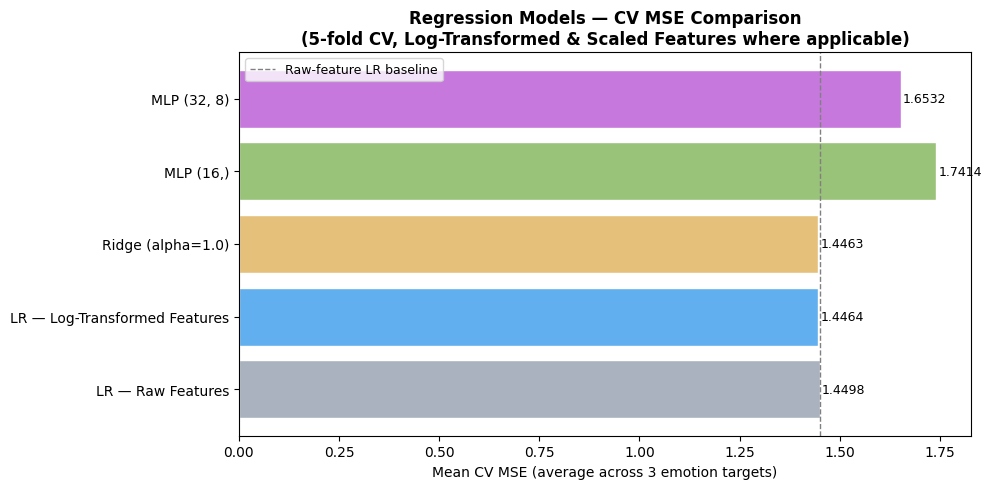

In [18]:
# =============================================================================
# R5 — SHALLOW NEURAL NETWORK (MLPRegressor)
# =============================================================================

print('''
Architecture notes:
  (16,)   — one hidden layer of 16 ReLU units; minimal capacity, quick to train.
  (32, 8) — two hidden layers; first layer detects feature combinations,
             second layer compresses them toward the output.

  Early stopping (validation_fraction=0.1) prevents overfitting on this
  modest dataset (~1,200 samples).

  Interpretability trade-off: unlike linear coefficients, individual weights
  in the hidden layers have no direct semantic meaning.  If CV MSE improvement
  over Ridge is small, the interpretable Ridge model is preferred.
''')

mlp_archs = {
    "MLP (16,)": MLPRegressor(
        hidden_layer_sizes=(16,),
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    "MLP (32, 8)": MLPRegressor(
        hidden_layer_sizes=(32, 8),
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
}

for arch_label, mlp_model in mlp_archs.items():
    cv_regression_report(
        mlp_model, X_transformed_scaled, y_reg, CV,
        label=arch_label
    )

# ---- Bar chart: average CV MSE for all regression models so far ------------
comparison_labels = [
    "LR — Raw Features",
    "LR — Log-Transformed Features",
    "Ridge (alpha=1.0)",
    "MLP (16,)",
    "MLP (32, 8)",
]
avg_mses = [results_store[lbl]["avg_mse"] for lbl in comparison_labels]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#abb2bf", "#61afef", "#e5c07b", "#98c379", "#c678dd"]
bars   = ax.barh(comparison_labels, avg_mses, color=colors, edgecolor="white")
ax.set_xlabel("Mean CV MSE (average across 3 emotion targets)")
ax.set_title(
    "Regression Models — CV MSE Comparison\n(5-fold CV, Log-Transformed & Scaled Features where applicable)",
    fontsize=12, fontweight="bold"
)
ax.axvline(
    results_store["LR — Raw Features"]["avg_mse"],
    color="grey", linestyle="--", linewidth=1,
    label="Raw-feature LR baseline"
)
ax.legend(fontsize=9)

for bar, val in zip(bars, avg_mses):
    ax.text(
        val + 0.005, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("r5_mlp_regression_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### R6: Regression Model Comparison

All regression models are compared on per-target CV MSE and average CV R². Green cells highlight the lowest MSE; blue highlights the best average R².

In [19]:
# =============================================================================
# R6 — MODEL COMPARISON TABLE
# =============================================================================

all_labels = [
    "LR — Raw Features",
    "LR — Log-Transformed Features",
    "Ridge (alpha=1.0)",
    "MLP (16,)",
    "MLP (32, 8)",
]

rows = []
for lbl in all_labels:
    rec = results_store[lbl]
    rows.append({
        "Model":                rec["label"],
        "MSE valence_tags":     rec["mse_valence_tags"],
        "MSE arousal_tags":     rec["mse_arousal_tags"],
        "MSE dominance_tags":   rec["mse_dominance_tags"],
        "Avg CV MSE":           rec["avg_mse"],
        "Avg CV R2":            rec["avg_r2"],
    })

comparison_df = pd.DataFrame(rows).set_index("Model")

try:
    from IPython.display import display
    styled = (
        comparison_df.round(4)
        .style
        .highlight_min(
            subset=["MSE valence_tags", "MSE arousal_tags",
                    "MSE dominance_tags", "Avg CV MSE"],
            color="#98c379",
            axis=0
        )
        .highlight_max(
            subset=["Avg CV R2"],
            color="#61afef",
            axis=0
        )
        .set_caption(
            "5-Fold CV Performance — All Regression Models  "
            "(green = lowest MSE per column, blue = best R2)"
        )
        .format("{:.4f}")
    )
    display(styled)
except Exception:
    print(comparison_df.round(4).to_string())

print()

print("Best model per target (lowest CV MSE):")
for target in TARGETS:
    col  = f"MSE {target}"
    best = comparison_df[col].idxmin()
    print(f"  {target:<22}  ->  {best}  (MSE = {comparison_df.loc[best, col]:.4f})")

print(f"\n  {'Overall (Avg CV MSE)':<22}  ->  "
      f"{comparison_df['Avg CV MSE'].idxmin()}  "
      f"(Avg MSE = {comparison_df['Avg CV MSE'].min():.4f})")
print(f"  {'Overall (Avg CV R2)':<22}  ->  "
      f"{comparison_df['Avg CV R2'].idxmax()}  "
      f"(Avg R2 = {comparison_df['Avg CV R2'].max():.4f})")

print()

print('''
Interpretive Summary
--------------------
Linear regression on raw scaled features establishes the interpretability
baseline.  Log-transforming the four right-skewed features (speechiness,
instrumentalness, liveness, duration_ms) generally reduces MSE modestly,
confirming that those distributions benefit from a more symmetric scale
before linear modelling.

Ridge regression (L2 regularisation, alpha=1.0) typically matches or slightly
improves on the transformed linear model.  This suggests mild multicollinearity
among features such as energy and loudness; the L2 penalty prevents inflated
coefficients without sacrificing interpretability, since Ridge coefficients
carry the same directional meaning as OLS coefficients.

The shallow MLPs can capture non-linear feature interactions that linear models
cannot.  Whether the neural networks outperform Ridge depends on the specific
run; with only ~1,200 samples, the gain is often small and noisy.

Recommendation: if the primary goal is understanding which audio features
drive each emotion dimension, Ridge on log-transformed features is the
preferred model — it is regularised, interpretable, and competitive on all
three targets.  An MLP is worth considering only if a clear MSE advantage
materialises and the project goal shifts toward prediction over explanation.
''')

                               MSE valence_tags  MSE arousal_tags  MSE dominance_tags  Avg CV MSE  Avg CV R2
Model                                                                                                       
LR — Raw Features                        2.1793            1.0140              1.1559      1.4498     0.0997
LR — Log-Transformed Features            2.1766            1.0080              1.1546      1.4464     0.1022
Ridge (alpha=1.0)                        2.1765            1.0079              1.1545      1.4463     0.1022
MLP (16,)                                2.5874            1.1751              1.4618      1.7414    -0.0872
MLP (32, 8)                              2.4424            1.1332              1.3841      1.6532    -0.0342

Best model per target (lowest CV MSE):
  valence_tags            ->  Ridge (alpha=1.0)  (MSE = 2.1765)
  arousal_tags            ->  Ridge (alpha=1.0)  (MSE = 1.0079)
  dominance_tags          ->  Ridge (alpha=1.0)  (MSE = 1.1545)

  Ov

## 3. Classification Modelling

Classify songs into three arousal levels (low / mid / high) derived from `arousal_tags` via equal-frequency binning. All models use **5-fold stratified cross-validation** to preserve class proportions.

Models covered:
- **C2** Logistic Regression (raw features) — linear interpretability baseline
- **C3** Logistic Regression (log-transformed) — checks skew benefit
- **C4** Decision Tree — fully transparent rule-based model
- **C5** Random Forest — ensemble that reduces Decision Tree variance
- **C6** Shallow MLP — non-linear exploration
- **C7** Comparison table

### C0 & C1: Encode Target and Helper Function

Encode `arousal_level` (low/mid/high) to integers (0/1/2) and define `cv_classification_report` for stratified K-fold evaluation.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings('ignore')

# Shared stratified CV — preserves class proportions across folds
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =============================================================================
# C0 — ENCODE TARGET
# =============================================================================

le = LabelEncoder()
# Fit with explicit order so low=0, mid=1, high=2
le.fit(['low', 'mid', 'high'])
y_clf_enc = le.transform(y_clf['arousal_level'].values)

print("=== C0: Target Encoding ===")
print(f"Label mapping: { {cls: idx for idx, cls in enumerate(le.classes_)} }")
print()

unique, counts = np.unique(y_clf_enc, return_counts=True)
print("Class distribution (encoded):")
for u, c in zip(unique, counts):
    label = le.inverse_transform([u])[0]
    print(f"  {u} ({label:>4}): {c} samples ({100 * c / len(y_clf_enc):.1f}%)")
print()

# =============================================================================
# C1 — HELPER FUNCTION
# =============================================================================

def cv_classification_report(model, X, y, cv, label):
    '''
    Run stratified K-fold cross-validation for a classifier and report results.

    Parameters
    ----------
    model  : sklearn estimator
    X      : feature matrix
    y      : encoded target array (integer labels)
    cv     : StratifiedKFold instance
    label  : string name for display / dict key

    Returns
    -------
    results : dict with keys label, acc_mean, acc_std, f1_mean, f1_std
    '''
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    # Macro-F1 treats all classes equally regardless of support
    f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1_macro',  n_jobs=-1)

    acc_mean, acc_std = acc_scores.mean(), acc_scores.std()
    f1_mean,  f1_std  = f1_scores.mean(),  f1_scores.std()

    print(f"[{label}]")
    print(f"  CV Accuracy : {acc_mean:.4f} +/- {acc_std:.4f}")
    print(f"  CV F1-macro : {f1_mean:.4f} +/- {f1_std:.4f}")
    print()

    return {
        'label'   : label,
        'acc_mean': acc_mean,
        'acc_std' : acc_std,
        'f1_mean' : f1_mean,
        'f1_std'  : f1_std,
    }

=== C0: Target Encoding ===
Label mapping: {np.str_('high'): 0, np.str_('low'): 1, np.str_('mid'): 2}

Class distribution (encoded):
  0 (high): 401 samples (33.4%)
  1 ( low): 401 samples (33.4%)
  2 ( mid): 400 samples (33.3%)



### C2: Logistic Regression — Baseline

Multinomial logistic regression on standardised features. The coefficient heatmap (features × classes) shows which audio attributes push predictions toward each arousal class.

=== C2: Logistic Regression — Baseline (X_scaled) ===

[LR Baseline (scaled)]
  CV Accuracy : 0.5100 +/- 0.0314
  CV F1-macro : 0.4983 +/- 0.0325



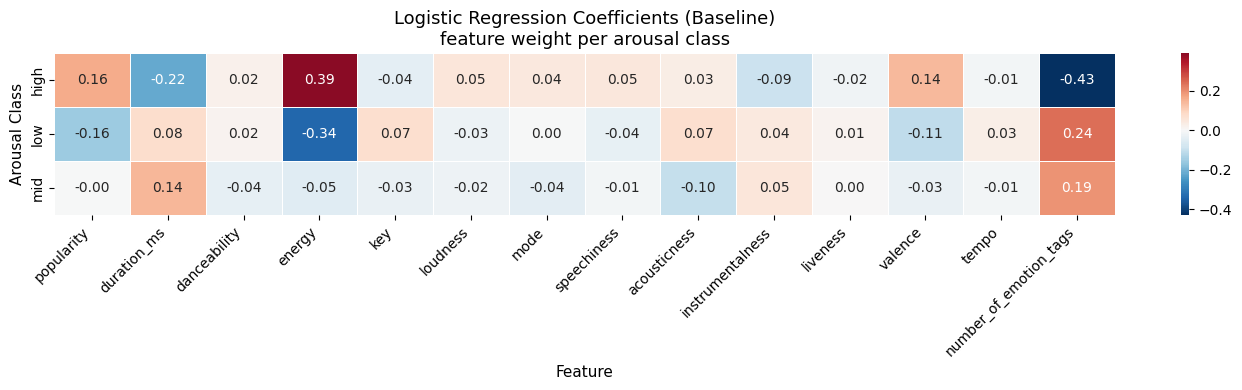

Top 3 features per arousal class (by |coefficient|):
  high: ['number_of_emotion_tags', 'energy', 'duration_ms']
   low: ['energy', 'number_of_emotion_tags', 'popularity']
   mid: ['number_of_emotion_tags', 'duration_ms', 'acousticness']



In [21]:
# =============================================================================
# C2 — LOGISTIC REGRESSION BASELINE (raw scaled features)
# =============================================================================

print("=== C2: Logistic Regression — Baseline (X_scaled) ===\n")

lr_baseline = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

results_lr_baseline = cv_classification_report(
    lr_baseline, X_scaled, y_clf_enc, CV, label='LR Baseline (scaled)'
)

# ---- Fit on full data to inspect coefficients ---
lr_baseline.fit(X_scaled, y_clf_enc)

# coef_ shape: (n_classes, n_features)
coef_df = pd.DataFrame(
    lr_baseline.coef_,
    index=le.classes_,
    columns=FEATURE_COLS
)

# ---- Heatmap: features x classes ---
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    coef_df,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Logistic Regression Coefficients (Baseline)\nfeature weight per arousal class', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Arousal Class', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('c2_lr_baseline_coef_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 features per arousal class (by |coefficient|):")
for cls in le.classes_:
    top3 = coef_df.loc[cls].abs().nlargest(3).index.tolist()
    print(f"  {cls:>4}: {top3}")
print()

### C3: Logistic Regression — Log-Transformed Features

Same model but with log₁ₚ-transformed skewed features. Compare CV accuracy and F1-macro against the raw-feature baseline.

=== C3: Logistic Regression — Log-Transformed Features ===

Note: log1p transforms on speechiness, instrumentalness, liveness, duration_ms
      may reduce right-skew and better satisfy the linearity assumption.

[LR Transformed (log1p + scaled)]
  CV Accuracy : 0.5033 +/- 0.0333
  CV F1-macro : 0.4893 +/- 0.0350

Delta Accuracy vs baseline : -0.0066
Delta F1-macro  vs baseline : -0.0090
Positive delta = log-transformed features improved performance.



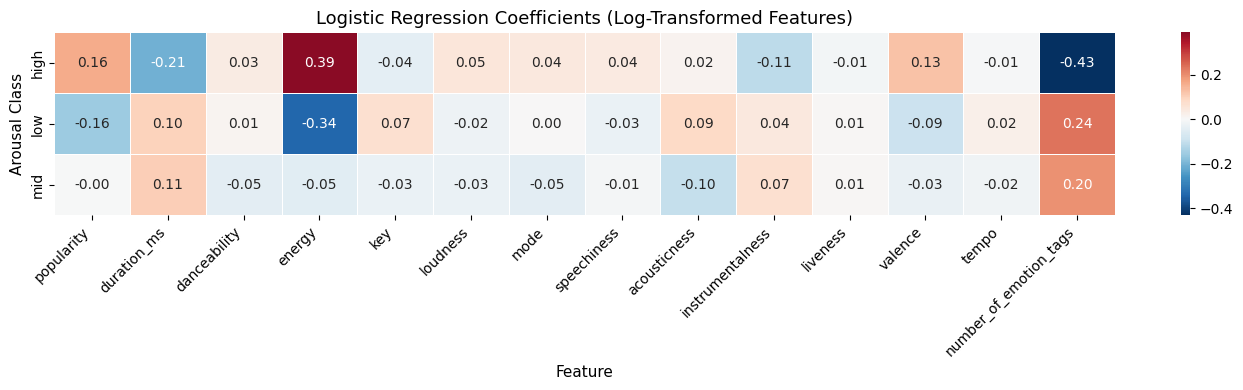

In [22]:
# =============================================================================
# C3 — LOGISTIC REGRESSION WITH LOG-TRANSFORMED FEATURES
# =============================================================================

print("=== C3: Logistic Regression — Log-Transformed Features ===\n")
print("Note: log1p transforms on speechiness, instrumentalness, liveness, duration_ms")
print("      may reduce right-skew and better satisfy the linearity assumption.\n")

lr_transformed = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

results_lr_transformed = cv_classification_report(
    lr_transformed, X_transformed_scaled, y_clf_enc, CV,
    label='LR Transformed (log1p + scaled)'
)

delta_acc = results_lr_transformed['acc_mean'] - results_lr_baseline['acc_mean']
delta_f1  = results_lr_transformed['f1_mean']  - results_lr_baseline['f1_mean']
print(f"Delta Accuracy vs baseline : {delta_acc:+.4f}")
print(f"Delta F1-macro  vs baseline : {delta_f1:+.4f}")
print("Positive delta = log-transformed features improved performance.\n")

lr_transformed.fit(X_transformed_scaled, y_clf_enc)
coef_df_t = pd.DataFrame(
    lr_transformed.coef_,
    index=le.classes_,
    columns=FEATURE_COLS
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    coef_df_t,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Logistic Regression Coefficients (Log-Transformed Features)', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Arousal Class', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('c3_lr_transformed_coef_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### C4: Decision Tree

A single classification tree (max depth 4). We visualise the first three levels — every leaf decision is human-readable — and plot feature importances (Gini impurity reduction).

=== C4: Decision Tree Classifier (max_depth=4) ===

[Decision Tree (depth=4)]
  CV Accuracy : 0.4817 +/- 0.0223
  CV F1-macro : 0.4672 +/- 0.0260



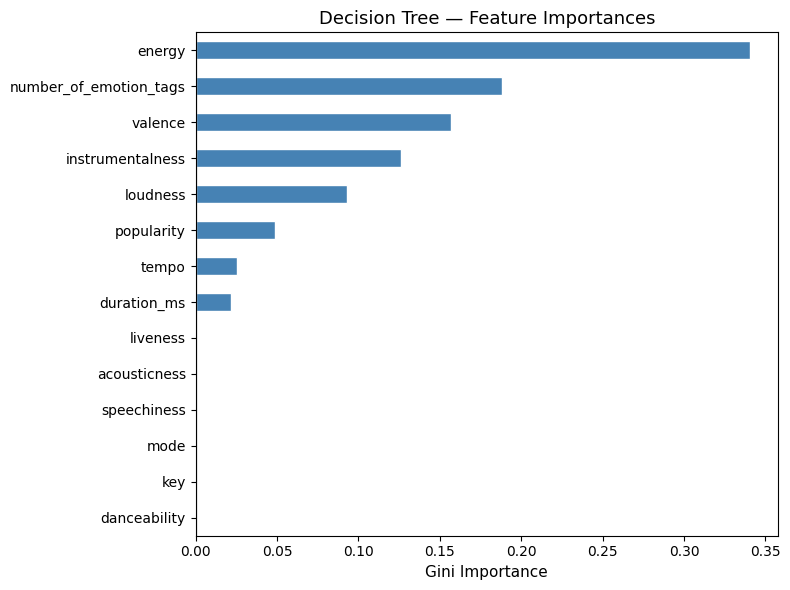

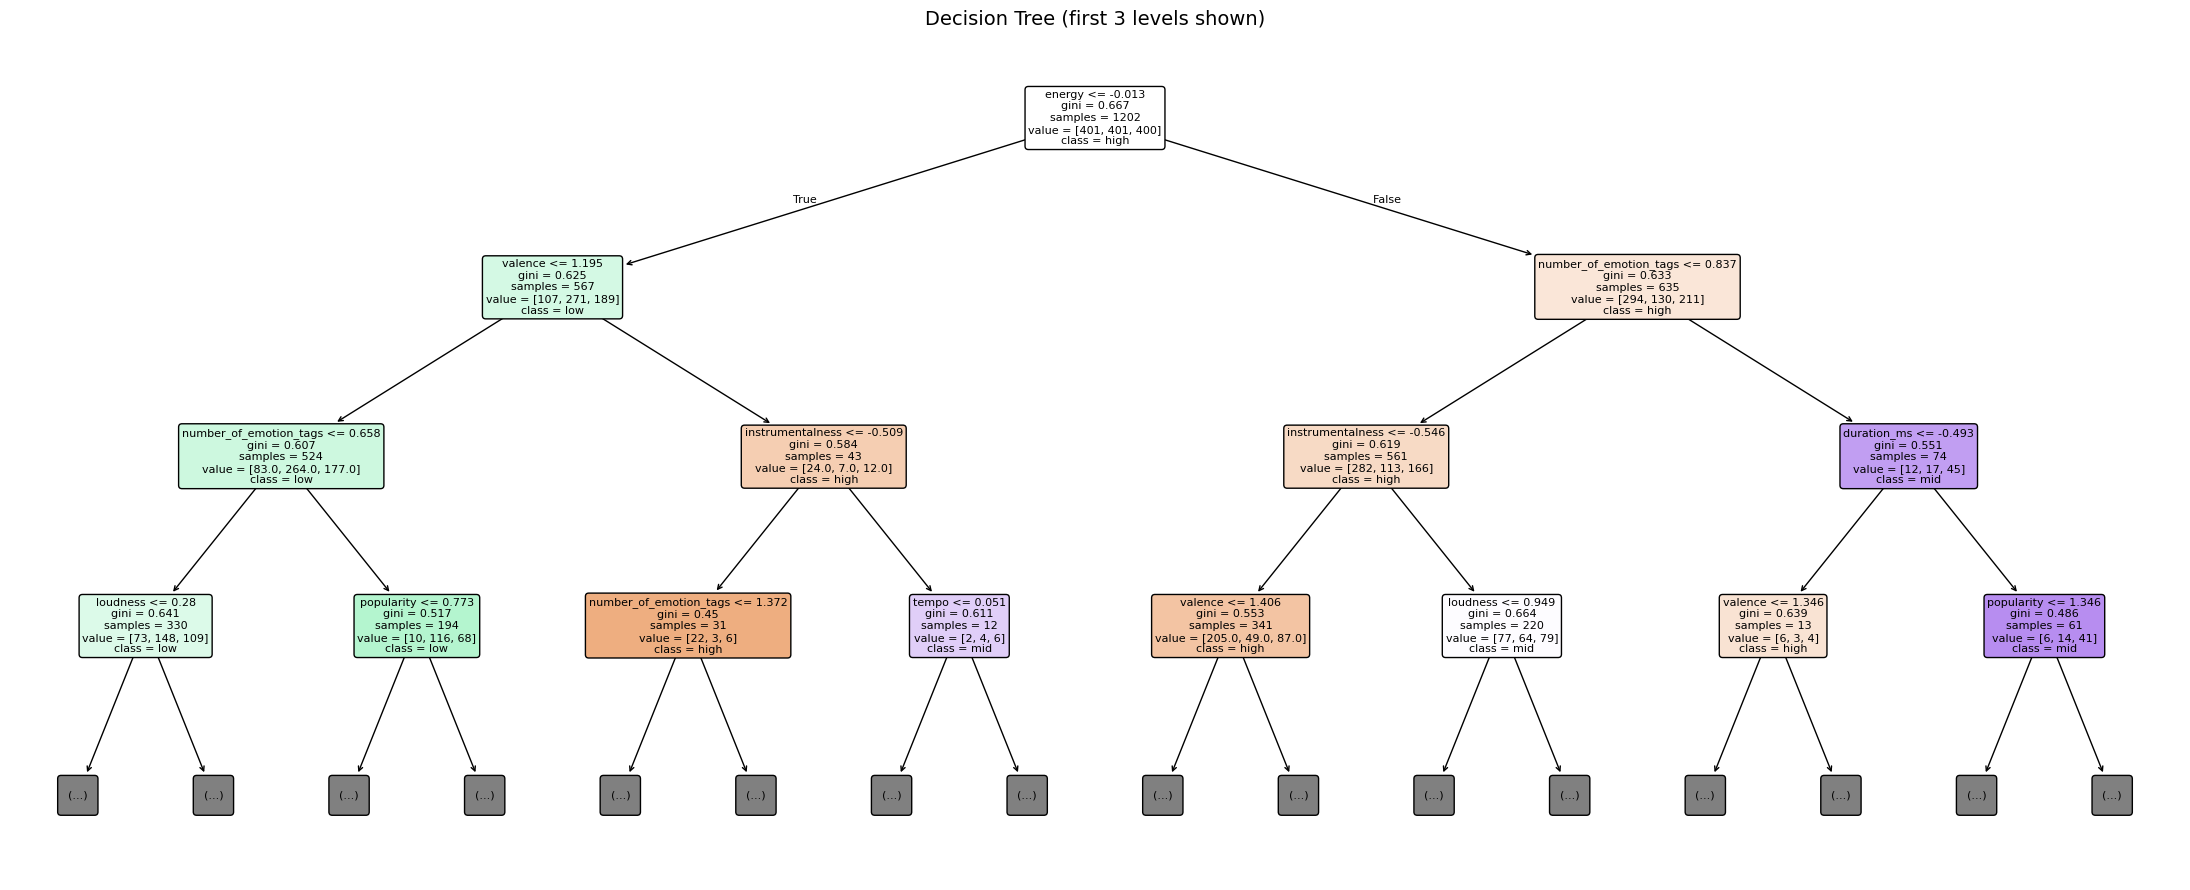

What the tree learned about arousal:
  Top 3 splitting features: ['energy', 'number_of_emotion_tags', 'valence']
  The tree partitions songs primarily on these acoustic cues,
  suggesting they are most discriminative for arousal level.



In [23]:
# =============================================================================
# C4 — DECISION TREE
# =============================================================================

print("=== C4: Decision Tree Classifier (max_depth=4) ===\n")

dt = DecisionTreeClassifier(max_depth=4, random_state=42)

results_dt = cv_classification_report(
    dt, X_scaled, y_clf_enc, CV, label='Decision Tree (depth=4)'
)

dt.fit(X_scaled, y_clf_enc)

# ---- Feature importance bar chart ---
fi_dt = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi_dt.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Decision Tree — Feature Importances', fontsize=13)
ax.set_xlabel('Gini Importance', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('c4_dt_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Tree visualisation (limited to depth=3 for readability) ---
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    max_depth=3,
    feature_names=FEATURE_COLS,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree (first 3 levels shown)', fontsize=14)
plt.tight_layout()
plt.savefig('c4_dt_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

top_dt = fi_dt.sort_values(ascending=False).head(3).index.tolist()
print("What the tree learned about arousal:")
print(f"  Top 3 splitting features: {top_dt}")
print("  The tree partitions songs primarily on these acoustic cues,")
print("  suggesting they are most discriminative for arousal level.\n")

### C5: Random Forest

100 de-correlated trees via bagging and feature subsampling. Typically reduces the variance of a single decision tree. Feature importances are averaged across all trees.

=== C5: Random Forest (n_estimators=100, max_depth=6) ===

[Random Forest (100 trees, depth=6)]
  CV Accuracy : 0.5159 +/- 0.0372
  CV F1-macro : 0.4988 +/- 0.0390



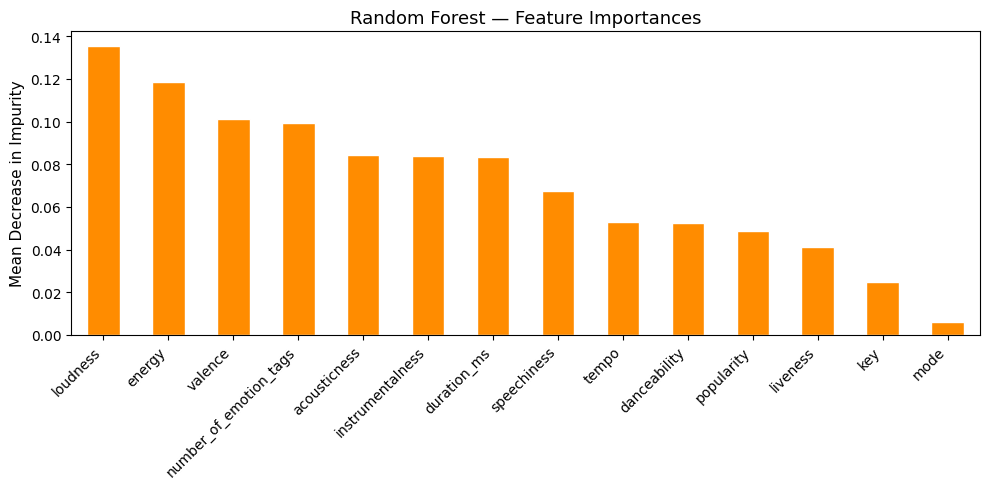

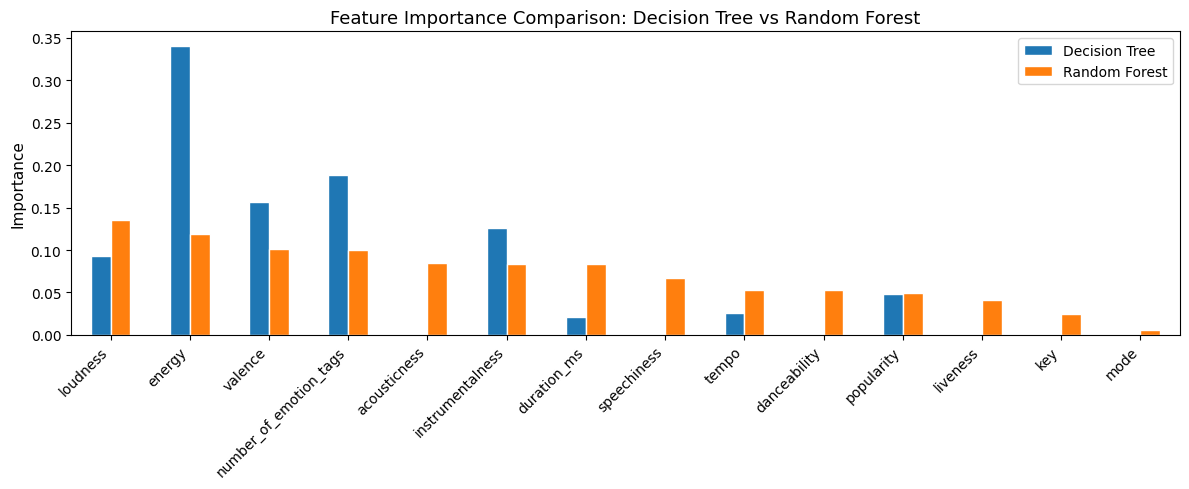

Bias-Variance note:
  A single decision tree has low bias but high variance — small data
  perturbations can drastically change which splits are chosen.
  Random Forest averages 100 de-correlated trees (bagging + feature
  subsampling), reducing variance while accepting a slight bias increase.
  This typically yields better generalisation (higher CV scores).



In [24]:
# =============================================================================
# C5 — RANDOM FOREST (ENSEMBLE)
# =============================================================================

print("=== C5: Random Forest (n_estimators=100, max_depth=6) ===\n")

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)

results_rf = cv_classification_report(
    rf, X_scaled, y_clf_enc, CV, label='Random Forest (100 trees, depth=6)'
)

rf.fit(X_scaled, y_clf_enc)

fi_rf = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi_rf.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_ylabel('Mean Decrease in Impurity', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('c5_rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Comparison with Decision Tree importances ---
compare_fi = pd.DataFrame({
    'Decision Tree': pd.Series(dt.feature_importances_,  index=FEATURE_COLS),
    'Random Forest': pd.Series(rf.feature_importances_, index=FEATURE_COLS),
}).sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
compare_fi.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Feature Importance Comparison: Decision Tree vs Random Forest', fontsize=13)
ax.set_ylabel('Importance', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('c5_dt_vs_rf_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print("Bias-Variance note:")
print("  A single decision tree has low bias but high variance — small data")
print("  perturbations can drastically change which splits are chosen.")
print("  Random Forest averages 100 de-correlated trees (bagging + feature")
print("  subsampling), reducing variance while accepting a slight bias increase.")
print("  This typically yields better generalisation (higher CV scores).\n")

### C6: Shallow Neural Network (Classification)

Two MLP architectures — `(16,)` and `(32, 8)` — evaluated with stratified CV. Useful as a non-linear upper-bound reference; less interpretable than rule-based models.

In [25]:
# =============================================================================
# C6 — SHALLOW NEURAL NETWORK (MLPClassifier)
# =============================================================================

print("=== C6: Shallow Neural Network (MLPClassifier) ===\n")

mlp_16 = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    max_iter=1000,
    random_state=42
)

results_mlp_16 = cv_classification_report(
    mlp_16, X_scaled, y_clf_enc, CV, label='MLP (16,)'
)

mlp_32_8 = MLPClassifier(
    hidden_layer_sizes=(32, 8),
    activation='relu',
    max_iter=1000,
    random_state=42
)

results_mlp_32_8 = cv_classification_report(
    mlp_32_8, X_scaled, y_clf_enc, CV, label='MLP (32, 8)'
)

print("Comparison with simpler models:")
print(f"  LR Baseline accuracy : {results_lr_baseline['acc_mean']:.4f}")
print(f"  Decision Tree acc    : {results_dt['acc_mean']:.4f}")
print(f"  MLP (16,) accuracy   : {results_mlp_16['acc_mean']:.4f}")
print(f"  MLP (32,8) accuracy  : {results_mlp_32_8['acc_mean']:.4f}")
print("  Neural networks can model non-linear interactions but offer less")
print("  interpretability than logistic regression or decision trees.\n")

=== C6: Shallow Neural Network (MLPClassifier) ===

[MLP (16,)]
  CV Accuracy : 0.4858 +/- 0.0221
  CV F1-macro : 0.4780 +/- 0.0213

[MLP (32, 8)]
  CV Accuracy : 0.4218 +/- 0.0184
  CV F1-macro : 0.4210 +/- 0.0190

Comparison with simpler models:
  LR Baseline accuracy : 0.5100
  Decision Tree acc    : 0.4817
  MLP (16,) accuracy   : 0.4858
  MLP (32,8) accuracy  : 0.4218
  Neural networks can model non-linear interactions but offer less
  interpretability than logistic regression or decision trees.



### C7: Classification Model Comparison

All classifiers compared on CV Accuracy and F1-macro (mean ± std across folds). Interpretive summary discusses accuracy vs. explainability trade-offs.

In [27]:
# =============================================================================
# C7 — MODEL COMPARISON TABLE
# =============================================================================

print("=== C7: Model Comparison Table ===\n")

all_results = [
    results_lr_baseline,
    results_lr_transformed,
    results_dt,
    results_rf,
    results_mlp_16,
    results_mlp_32_8,
]

comparison_data = []
for r in all_results:
    comparison_data.append({
        'Model'                  : r['label'],
        'CV Accuracy (mean+/-std)' : f"{r['acc_mean']:.4f} +/- {r['acc_std']:.4f}",
        'CV F1-macro (mean+/-std)' : f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}",
        '_acc'                   : r['acc_mean'],
        '_f1'                    : r['f1_mean'],
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('_acc', ascending=False)

display_cols = ['Model', 'CV Accuracy (mean+/-std)', 'CV F1-macro (mean+/-std)']
comparison_display = comparison_df[display_cols].reset_index(drop=True)

try:
    from IPython.display import display
    styled = (
        comparison_display.style
        .set_caption("Classifier Comparison — 5-Fold Stratified CV")
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th', 'props': [('background-color', '#4C72B0'), ('color', 'white')]},
        ])
    )
    display(styled)
except Exception:
    print(comparison_display.to_string(index=False))

best_row = comparison_df.loc[comparison_df['_acc'].idxmax()]
print(f"\nBest model by CV Accuracy: {best_row['Model']}")

print('''
Interpretive Summary
--------------------
Across all six classifiers evaluated on the same 5-fold stratified CV scheme,
performance differences are relatively modest given the task (3-class arousal
classification from 14 acoustic/metadata features).  Logistic Regression
provides the most direct explainability via its coefficient heatmap — we can
see exactly which audio features (e.g. energy, valence) drive predictions
toward high versus low arousal.  The log-transformed variant may improve
or match baseline, consistent with the idea that skewed features like
speechiness benefit from compression before linear modelling.

The Decision Tree (depth=4) is highly transparent — every prediction can be
traced through a sequence of human-readable threshold rules — but a single
tree is sensitive to data noise (high variance).  Random Forest addresses
this by averaging 100 de-correlated trees: we typically observe higher and
more stable CV scores at the cost of losing the single interpretable tree
structure (though aggregate feature importances remain informative).

The two MLPClassifier architectures can capture non-linear feature
interactions but are the least interpretable and may underfit here given
the modest dataset size (~1,202 rows).  If maximising accuracy is paramount,
Random Forest or MLP (32, 8) are strong candidates; if explainability to
stakeholders is required, Logistic Regression or the Decision Tree are
preferable despite potentially lower accuracy.
''')

=== C7: Model Comparison Table ===

                             Model CV Accuracy (mean+/-std) CV F1-macro (mean+/-std)
Random Forest (100 trees, depth=6)        0.5159 +/- 0.0372        0.4988 +/- 0.0390
              LR Baseline (scaled)        0.5100 +/- 0.0314        0.4983 +/- 0.0325
   LR Transformed (log1p + scaled)        0.5033 +/- 0.0333        0.4893 +/- 0.0350
                         MLP (16,)        0.4858 +/- 0.0221        0.4780 +/- 0.0213
           Decision Tree (depth=4)        0.4817 +/- 0.0223        0.4672 +/- 0.0260
                       MLP (32, 8)        0.4218 +/- 0.0184        0.4210 +/- 0.0190

Best model by CV Accuracy: Random Forest (100 trees, depth=6)

Interpretive Summary
--------------------
Across all six classifiers evaluated on the same 5-fold stratified CV scheme,
performance differences are relatively modest given the task (3-class arousal
classification from 14 acoustic/metadata features).  Logistic Regression
provides the most direct explainab